# Notebook 07: Advanced Machine Learning Baselines & Feature Diagnostics

##  Σύνοψη Φάσης
Σε αυτό το notebook ολοκληρώνεται η διαδικασία του **Benchmarking**. Μετά την υλοποίηση των απλών μοντέλων (Persistence, Linear Regression) στο Notebook 06, περνάμε σε πιο σύνθετους αλγορίθμους Machine Learning και Deep Learning. 

Ο στόχος είναι να καθοριστεί το "State-of-the-Art" επίπεδο των κλασικών προσεγγίσεων, το οποίο θα αποτελέσει το μέτρο σύγκρισης για τις Spatio-Temporal αρχιτεκτονικές (GNN, Mamba) που θα ακολουθήσουν.

##  Στόχοι
1. **Data Standardization:** Εφαρμογή Z-score scaling για τη διασφάλιση της σύγκλισης των νευρωνικών δικτύων.
2. **Ensemble Learning:** Εκπαίδευση **Random Forest** και **XGBoost** για τη μοντελοποίηση των μη-γραμμικών σχέσεων.
3. **Deep Learning Baseline:** Υλοποίηση ενός **Multi-Layer Perceptron (MLP)** ως βασική αρχιτεκτονική νευρωνικού.
4. **Feature Importance Analysis:** Ταυτοποίηση των πιο επιδραστικών μεταβλητών (Feature Selection) για τη μείωση της πολυπλοκότητας στα επόμενα στάδια.

##  Μεθοδολογία Προετοιμασίας
Για την εκπαίδευση των προηγμένων μοντέλων, απαιτείται η κανονικοποίηση των χαρακτηριστικών. Χρησιμοποιούμε τον **StandardScaler**, ο οποίος μετασχηματίζει τα δεδομένα ώστε να έχουν μέση τιμή 0 και τυπική απόκλιση 1:

$$z = \frac{x - \mu}{\sigma}$$

Αυτό είναι απαραίτητο για το **MLP**, καθώς οι κλίσεις (gradients) είναι ευαίσθητες στις διαφορές κλίμακας μεταξύ των μεταβλητών (π.χ. Ταχύτητα Ανέμου vs Ατμοσφαιρική Πίεση).

##  Non-Linear Modeling: Random Forest & XGBoost
Σε αυτή την ενότητα χρησιμοποιούμε μοντέλα βασισμένα σε δέντρα απόφασης. Τα μοντέλα αυτά είναι εξαιρετικά ανθεκτικά σε outliers και μπορούν να συλλάβουν τις μη-γραμμικές αλληλεπιδράσεις μεταξύ των καιρικών παραμέτρων και της παραγόμενης ισχύος, τις οποίες η Linear Regression αδυνατούσε να προσεγγίσει.

# Notebook 07: Random Forest Baseline with Train / Validation / Test Protocol

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Σύνδεση με το src/config
sys.path.append(str(Path.cwd().parent))
from src.config import DATA_PROCESSED, TARGET_COLUMN

# ------------------------------------------------------------------
# 1. Load final processed splits
# ------------------------------------------------------------------
train_df = pd.read_csv(DATA_PROCESSED / "train_final.csv")
val_df   = pd.read_csv(DATA_PROCESSED / "val_final.csv")
test_df  = pd.read_csv(DATA_PROCESSED / "test_final.csv")

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

# ------------------------------------------------------------------
# 2. Define target
# ------------------------------------------------------------------
y_train = train_df[TARGET_COLUMN]
y_val   = val_df[TARGET_COLUMN]
y_test  = test_df[TARGET_COLUMN]

# ------------------------------------------------------------------
# 3. Define candidate features
#    Start from numeric columns and remove the target.
#    Keep this explicit and inspect the final list.
# ------------------------------------------------------------------
feature_cols = [
    col for col in train_df.select_dtypes(include=[np.number]).columns
    if col != TARGET_COLUMN
]

print(f"Number of candidate features: {len(feature_cols)}")
print("First 20 features:", feature_cols[:20])

X_train = train_df[feature_cols].copy()
X_val   = val_df[feature_cols].copy()
X_test  = test_df[feature_cols].copy()

Train shape: (1244004, 41)
Val shape: (329084, 41)
Test shape: (82797, 41)
Number of candidate features: 39
First 20 features: ['nwp_fcst_horiz_hours', 'T_HAG_2_M', 'RELHUM_HAG_2_M', 'PS_SFC_0_M', 'U_GVL_58_HL', 'V_GVL_58_HL', 'U_GVL_60_HL', 'V_GVL_60_HL', 'ASWDIFDS_SFC_0_M', 'ASWDIRS_SFC_0_M', 'U_GVL_58_HL_m1', 'V_GVL_58_HL_m1', 'U_GVL_60_HL_m1', 'V_GVL_60_HL_m1', 'U_GVL_58_HL_p1', 'V_GVL_58_HL_p1', 'U_GVL_60_HL_p1', 'V_GVL_60_HL_p1', 'ws_ref', 'Wind_Speed_100m_ms']


In [2]:
# ---------------------------------------------------------------------
# FEATURE AUDIT: Full candidate feature list
# ---------------------------------------------------------------------
# Scientific purpose:
# Before training any baseline model, we must inspect the predictor set
# explicitly. This is especially important in forecasting pipelines,
# because helper columns, identifiers, or future-derived variables may
# introduce shortcut behavior or indirect leakage.
#
# At this stage, we do NOT modify the feature list yet.
# We simply print the full set of candidate predictors so that the
# final modeling space is transparent and auditable.
# ---------------------------------------------------------------------

print("Full candidate feature list:")
for i, col in enumerate(feature_cols, start=1):
    print(f"{i:02d}. {col}")

Full candidate feature list:
01. nwp_fcst_horiz_hours
02. T_HAG_2_M
03. RELHUM_HAG_2_M
04. PS_SFC_0_M
05. U_GVL_58_HL
06. V_GVL_58_HL
07. U_GVL_60_HL
08. V_GVL_60_HL
09. ASWDIFDS_SFC_0_M
10. ASWDIRS_SFC_0_M
11. U_GVL_58_HL_m1
12. V_GVL_58_HL_m1
13. U_GVL_60_HL_m1
14. V_GVL_60_HL_m1
15. U_GVL_58_HL_p1
16. V_GVL_58_HL_p1
17. U_GVL_60_HL_p1
18. V_GVL_60_HL_p1
19. ws_ref
20. Wind_Speed_100m_ms
21. test_flag
22. Baseline_Prediction
23. park_id
24. hour
25. month
26. hour_sin
27. hour_cos
28. month_sin
29. month_cos
30. Power_Output_Normalized_lag_1
31. Power_Output_Normalized_lag_3
32. Power_Output_Normalized_lag_6
33. Wind_Speed_100m_ms_lag_1
34. Wind_Speed_100m_ms_lag_3
35. Wind_Speed_100m_ms_lag_6
36. power_rolling_mean_6h
37. power_rolling_std_6h
38. lat
39. lon


In [3]:
# ---------------------------------------------------------------------
# FEATURE AUDIT: Search for potentially problematic columns
# ---------------------------------------------------------------------
# Scientific purpose:
# This diagnostic scan helps detect columns that may require manual
# review before modeling. We are not claiming that such columns are
# automatically invalid; rather, we flag them for methodological review.
#
# Why this matters:
# - "id" type variables may act as entity shortcuts rather than real
#   predictive signals.
# - time/date helper columns may encode split structure or indexing logic.
# - prediction/helper columns must be consciously justified if included.
# ---------------------------------------------------------------------

suspicious_patterns = [
    "id", "index", "time", "date", "timestamp", "target", "future", "pred"
]

print("Potentially suspicious columns:")
found_any = False

for col in feature_cols:
    col_lower = col.lower()
    if any(pattern in col_lower for pattern in suspicious_patterns):
        print("-", col)
        found_any = True

if not found_any:
    print("No potentially suspicious columns detected by pattern scan.")

Potentially suspicious columns:
- Baseline_Prediction
- park_id


In [4]:
# ---------------------------------------------------------------------
# FEATURE POLICY: Explicit exclusions for the first clean RF baseline
# ---------------------------------------------------------------------
# Scientific rationale:
# We exclude variables that should not participate in the first strict
# Random Forest baseline for the following reasons:
#
# 1. test_flag:
#    This is a helper / split-related variable and must not be used as
#    a predictor in the forecasting model.
#
# 2. park_id:
#    This is an identifier rather than a physical explanatory variable.
#    Keeping it may allow the model to learn entity shortcuts instead of
#    generalizable predictive structure.
#
# 3. Baseline_Prediction:
#    Although this may be a valid forecast-time input in some settings,
#    we exclude it from the first clean RF benchmark so that the model
#    remains a standalone nonlinear baseline rather than a forecast-
#    assisted or stacking-style variant.
# ---------------------------------------------------------------------

columns_to_exclude = [
    "test_flag",
    "park_id",
    "Baseline_Prediction",
]

feature_cols = [col for col in feature_cols if col not in columns_to_exclude]

print("Final feature list for the first clean RF baseline:")
for i, col in enumerate(feature_cols, start=1):
    print(f"{i:02d}. {col}")

print(f"\nFinal number of features: {len(feature_cols)}")

Final feature list for the first clean RF baseline:
01. nwp_fcst_horiz_hours
02. T_HAG_2_M
03. RELHUM_HAG_2_M
04. PS_SFC_0_M
05. U_GVL_58_HL
06. V_GVL_58_HL
07. U_GVL_60_HL
08. V_GVL_60_HL
09. ASWDIFDS_SFC_0_M
10. ASWDIRS_SFC_0_M
11. U_GVL_58_HL_m1
12. V_GVL_58_HL_m1
13. U_GVL_60_HL_m1
14. V_GVL_60_HL_m1
15. U_GVL_58_HL_p1
16. V_GVL_58_HL_p1
17. U_GVL_60_HL_p1
18. V_GVL_60_HL_p1
19. ws_ref
20. Wind_Speed_100m_ms
21. hour
22. month
23. hour_sin
24. hour_cos
25. month_sin
26. month_cos
27. Power_Output_Normalized_lag_1
28. Power_Output_Normalized_lag_3
29. Power_Output_Normalized_lag_6
30. Wind_Speed_100m_ms_lag_1
31. Wind_Speed_100m_ms_lag_3
32. Wind_Speed_100m_ms_lag_6
33. power_rolling_mean_6h
34. power_rolling_std_6h
35. lat
36. lon

Final number of features: 36


In [5]:
# ---------------------------------------------------------------------
# FINAL FEATURE MATRICES
# ---------------------------------------------------------------------
# After finalizing the predictor set, we rebuild the train / validation /
# test matrices using exactly the same columns across all splits.
# This guarantees consistency and reproducibility.
# ---------------------------------------------------------------------

X_train = train_df[feature_cols].copy()
X_val   = val_df[feature_cols].copy()
X_test  = test_df[feature_cols].copy()

print("Feature matrix shapes:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

Feature matrix shapes:
X_train: (1244004, 36)
X_val:   (329084, 36)
X_test:  (82797, 36)


In [6]:
# ---------------------------------------------------------------------
# SANITY CHECK
# ---------------------------------------------------------------------
# Confirm that excluded columns are no longer present in the modeling
# matrices before any training step is executed.
# ---------------------------------------------------------------------

for forbidden_col in columns_to_exclude:
    assert forbidden_col not in X_train.columns, f"{forbidden_col} still exists in X_train"
    assert forbidden_col not in X_val.columns, f"{forbidden_col} still exists in X_val"
    assert forbidden_col not in X_test.columns, f"{forbidden_col} still exists in X_test"

print("Sanity check passed: excluded columns are not present in the feature matrices.")

Sanity check passed: excluded columns are not present in the feature matrices.


In [8]:
# ---------------------------------------------------------------------
# REGRESSION METRICS
# ---------------------------------------------------------------------
# We use the core regression metrics of the benchmark protocol:
# - MAE
# - RMSE
# - R2
# ---------------------------------------------------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [9]:
# ---------------------------------------------------------------------
# RANDOM FOREST: Validation-based model selection
# ---------------------------------------------------------------------
# Scientific purpose:
# We train a small set of Random Forest configurations ONLY on the train
# split and compare them ONLY on the validation split.
#
# Why this is important:
# The validation set is used for model selection, while the test set
# remains untouched until the very end. This preserves the integrity of
# the final benchmark.
# ---------------------------------------------------------------------

from sklearn.ensemble import RandomForestRegressor
import pandas as pd

rf_configs = [
    {"n_estimators": 50,  "max_depth": 8,  "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 100, "max_depth": 10, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 100, "max_depth": 12, "min_samples_leaf": 2, "max_features": "sqrt"},
]

val_results = []

for cfg in rf_configs:
    print(f"Training Random Forest with config: {cfg}")

    rf = RandomForestRegressor(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        min_samples_leaf=cfg["min_samples_leaf"],
        max_features=cfg["max_features"],
        n_jobs=-1,
        random_state=42
    )

    # Training is performed only on the train split
    rf.fit(X_train, y_train)

    # Validation predictions
    val_preds = rf.predict(X_val)

    # Validation metrics
    val_metrics = regression_metrics(y_val, val_preds)

    result_row = {
        "Model": "Random Forest",
        "n_estimators": cfg["n_estimators"],
        "max_depth": cfg["max_depth"],
        "min_samples_leaf": cfg["min_samples_leaf"],
        "max_features": cfg["max_features"],
        "MAE": val_metrics["MAE"],
        "RMSE": val_metrics["RMSE"],
        "R2": val_metrics["R2"]
    }

    val_results.append(result_row)

val_results_df = (
    pd.DataFrame(val_results)
    .sort_values(by="MAE", ascending=True)
    .reset_index(drop=True)
)

print("\nValidation ranking of Random Forest configurations:")
display(val_results_df)

Training Random Forest with config: {'n_estimators': 50, 'max_depth': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Training Random Forest with config: {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Training Random Forest with config: {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 2, 'max_features': 'sqrt'}

Validation ranking of Random Forest configurations:


,Model,n_estimators,max_depth,min_samples_leaf,max_features,MAE,RMSE,R2
0,Random Forest,100,12,2,sqrt,0.007428,0.010082,0.542893
1,Random Forest,100,10,1,sqrt,0.007716,0.010368,0.516636
2,Random Forest,50,8,1,sqrt,0.008004,0.010660,0.488980


In [10]:
# ---------------------------------------------------------------------
# BEST VALIDATION CONFIGURATION
# ---------------------------------------------------------------------
# Επιλέγουμε τη ρύθμιση με το χαμηλότερο validation MAE.
# Αυτό αποτελεί το model-selection βήμα του experiment.
# ---------------------------------------------------------------------

best_row = val_results_df.iloc[0]

best_params = {
    "n_estimators": int(best_row["n_estimators"]),
    "max_depth": int(best_row["max_depth"]),
    "min_samples_leaf": int(best_row["min_samples_leaf"]),
    "max_features": best_row["max_features"],
}

print("Best validation configuration:")
print(best_params)

print("\nValidation metrics of the selected configuration:")
print(best_row[["MAE", "RMSE", "R2"]])

Best validation configuration:
{'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 2, 'max_features': 'sqrt'}

Validation metrics of the selected configuration:
MAE     0.007428
RMSE    0.010082
R2      0.542893
Name: 0, dtype: object


In [11]:
# ---------------------------------------------------------------------
# FINAL TEST EVALUATION
# ---------------------------------------------------------------------
# Το test split χρησιμοποιείται μόνο τώρα, αφού έχει ήδη ολοκληρωθεί
# η επιλογή του καλύτερου configuration μέσω του validation split.
# Έτσι διατηρείται η αξιοπιστία του τελικού benchmark.
# ---------------------------------------------------------------------

from sklearn.ensemble import RandomForestRegressor

best_rf = RandomForestRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    min_samples_leaf=best_params["min_samples_leaf"],
    max_features=best_params["max_features"],
    n_jobs=-1,
    random_state=42
)

# Εκπαίδευση μόνο στο train split
best_rf.fit(X_train, y_train)

# Τελικές προβλέψεις στο test split
test_preds = best_rf.predict(X_test)

# Τελικά metrics
test_metrics = regression_metrics(y_test, test_preds)

print("Final Random Forest test metrics:")
for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value:.6f}")

Final Random Forest test metrics:
MAE: 0.007260
RMSE: 0.009845
R2: 0.526639


In [12]:
# ---------------------------------------------------------------------
# FINAL BENCHMARK ROW
# ---------------------------------------------------------------------
# Αποθηκεύουμε το τελικό αποτέλεσμα του Random Forest σε compact μορφή
# ώστε να μπορεί να ενσωματωθεί στο κοινό benchmark table.
# ---------------------------------------------------------------------

import pandas as pd

rf_test_row = pd.DataFrame([
    {
        "Model": "Random Forest",
        "MAE": test_metrics["MAE"],
        "RMSE": test_metrics["RMSE"],
        "R2": test_metrics["R2"]
    }
])

display(rf_test_row)

,Model,MAE,RMSE,R2
0,Random Forest,0.00726,0.009845,0.526639


In [13]:
# ---------------------------------------------------------------------
# OPTIONAL: SAVE / UPDATE BENCHMARK CSV
# ---------------------------------------------------------------------
# Αν υπάρχει benchmark CSV, ενημερώνεται με το νέο αποτέλεσμα του
# Random Forest. Αν δεν υπάρχει, δημιουργείται νέο αρχείο.
# ---------------------------------------------------------------------

benchmark_path = DATA_PROCESSED / "baseline_metrics.csv"

if benchmark_path.exists():
    benchmark_df = pd.read_csv(benchmark_path)
    print("Existing benchmark file found.")
else:
    benchmark_df = pd.DataFrame(columns=["Model", "MAE", "RMSE", "R2"])
    print("No benchmark file found. A new one will be created.")

required_cols = ["Model", "MAE", "RMSE", "R2"]

benchmark_df = pd.concat(
    [benchmark_df[required_cols], rf_test_row[required_cols]],
    ignore_index=True
)

benchmark_df = benchmark_df.drop_duplicates(subset=["Model"], keep="last")
benchmark_df = benchmark_df.sort_values(by="MAE", ascending=True).reset_index(drop=True)

display(benchmark_df)

benchmark_df.to_csv(benchmark_path, index=False)
print(f"Benchmark saved to: {benchmark_path}")

Existing benchmark file found.


,Model,MAE,RMSE,R2
0,Random Forest,0.007260,0.009845,0.526639
1,Linear Regression,0.008566,0.010984,0.409470
2,Persistence,0.009313,0.014394,-0.014148


Benchmark saved to: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\baseline_metrics.csv


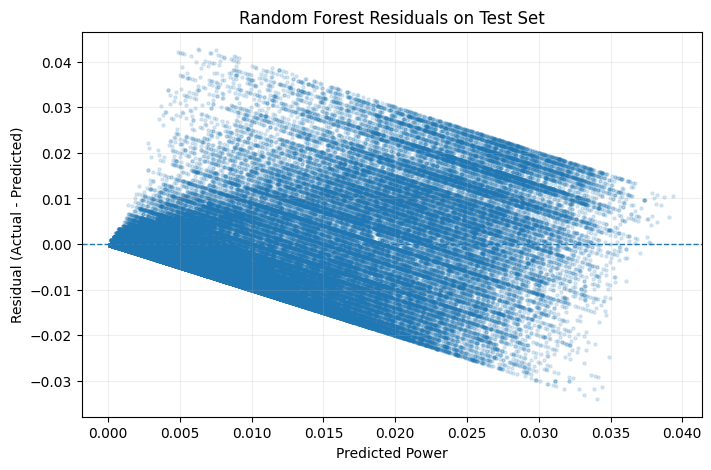

In [14]:
# ---------------------------------------------------------------------
# DIAGNOSTIC PLOT: Residuals vs predicted values
# ---------------------------------------------------------------------
# Το διάγραμμα residuals δίνει μια πρώτη εικόνα για το αν το μοντέλο
# παρουσιάζει systematic bias ή έντονη δομή σφάλματος.
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt

residuals = y_test - test_preds

plt.figure(figsize=(8, 5))
plt.scatter(test_preds, residuals, alpha=0.15, s=5)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Predicted Power")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Random Forest Residuals on Test Set")
plt.grid(alpha=0.2)
plt.show()